#**Benchmark & Pipeline ML — NYC Taxi**
####Trabalho realizado para disciplina de Ciência de Dados em Larga Escala
#####**Grupo:** Renata Azevedo (up202512262), Giuliano (up) e Ni (up202205842)

19.   **Experimento 6.2 - Cudf para Machine Learning**


### Tarefa ML: Prever `fare_amount` (tarifa da viagem)

| Modelo | Tipo | Alvo |
|---|---|---|
| **XGBRegressor** | Regressão | `fare_amount` contínuo |
| **LogisticRegression** | Classificação | `fare_amount` discretizado em 4 classes |

Estratégia de Implementação

O pipeline de Machine Learning foi desenvolvido para execução em ambiente Google Colab com GPU T4, utilizando a stack NVIDIA RAPIDS (cuDF + cuML) para acelerar operações de processamento e modelação diretamente na GPU.

Apesar do uso de GPU, o ambiente mantém restrições.

Foram aplicadas as seguintes estratégias:

1. Utilização de GPU (RAPIDS)
- Substituição de Pandas → cuDF para operações de dados
- Substituição de Scikit-learn → cuML para modelos de ML
- Execução de treino e inferência diretamente na GPU (T4)
- Redução significativa do tempo de treino em operações paralelizáveis
2. Controlo de carga computacional
Utilização de amostragem controlada do dataset (ordem de milhões de registos)
- Conversões explícitas entre GPU ↔ CPU apenas quando necessário para métricas (.to_numpy())
- Evitar operações que forçam transferência excessiva GPU→CPU

>19.1.   **Configuração do Ambiente**


Instalação da biblioteca de processamento de dados:


In [1]:
# ============================================================
# INSTALAÇÕES — execute apenas uma vez no Colab
# Descomente as linhas necessárias e volte a comentar após instalar
# ============================================================

# !pip install dask[complete] pyarrow          # Dask
#!pip install modin[ray]                      # Modin (backend Ray)
# !pip install pyspark                         # PySpark / Koalas
# !pip install xgboost                         # XGBoost
# !pip install yappi                           # Profiling multi-thread

# RAPIDS (só com GPU NVIDIA no Colab — ativar runtime GPU primeiro):
#!pip install cudf-cu12 cuml-cu12 --extra-index-url=https://pypi.nvidia.com

print("OK.")

OK.


Iniciando a leitura com algumas importações necessárias:

In [2]:
#============================================================
# IMPORTS GERAIS
# ============================================================
import os, time, warnings, urllib.request, gc
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

print(f"Pandas  : {pd.__version__}")
print(f"NumPy   : {np.__version__}")
print(f"Data    : {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Pandas  : 2.2.2
NumPy   : 2.0.2
Data    : 2026-06-03 19:37


In [3]:
# ============================================================
# IMPORTS DAS BIBLIOTECAS BIG DATA
# try/except: o notebook não quebra se uma lib não estiver instalada
# ============================================================

# Injeta dicionário vazio para compatibilidade do Spark com Pandas recente
if not hasattr(pd.core.common, '_builtin_table'):
    pd.core.common._builtin_table = {}


# --- RAPIDS cuDF (GPU) ---
# [ADICIONADO] — Rapids não estava no notebook original
try:
    import cudf
    import cupy as cp
    print(f" cuDF (GPU)  : {cudf.__version__}")
    CUDF_AVAILABLE = True
except ImportError:
    print(" cuDF não disponível (sem GPU NVIDIA/CUDA)")
    CUDF_AVAILABLE = False
import cudf


# --- XGBoost ---
# [ADICIONADO] — necessário para o Pipeline ML
try:
    import xgboost as xgb
    print(f" XGBoost     : {xgb.__version__}")
    XGB_AVAILABLE = True
except ImportError:
    print(" XGBoost não disponível (pip install xgboost)")
    XGB_AVAILABLE = False

# --- Scikit-learn ---
try:
    import sklearn
    print(f" Scikit-learn: {sklearn.__version__}")
except ImportError:
    print(" Scikit-learn não disponível")

 cuDF (GPU)  : 26.02.01
 XGBoost     : 3.2.0
 Scikit-learn: 1.6.1


In [4]:
# ── [NOVO] Imports ML ───────────────────────────────────────

from sklearn.pipeline        import Pipeline

# ── cuML (Machine Learning GPU) ─────────────────────────────
from cuml.linear_model import LogisticRegression as cuLR
from cuml.preprocessing import StandardScaler
from cuml.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, StratifiedKFold
# ── XGBoost GPU ─────────────────────────────────────────────
import xgboost as xgb
from sklearn.datasets        import load_iris
import cupy as cp
# ── SKLEARN (apenas métricas + fallback CPU se necessário) ──
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.model_selection import StratifiedKFold, GridSearchCV
print(" Imports ML OK")

 Imports ML OK


In [5]:
# ============================================================
# CONFIGURAÇÃO GLOBAL
# Altere apenas estas variáveis para escalar o experimento
# ============================================================

ANO       = 2026   # Ano dos dados NYC Taxi
NUM_MESES = 12      # Número de meses a descarregar (1 = ~61 MB; 12 = ~730 MB)
caminho   = Path("./FileStore/taxi/csv2026")  # Pasta local dos dados

caminho.mkdir(parents=True, exist_ok=True)
print(f" Pasta: {caminho.resolve()}")
print(f" Período: {ANO}, meses 1 a {NUM_MESES}")

 Pasta: /content/FileStore/taxi/csv2026
 Período: 2026, meses 1 a 12


In [6]:
# Lista os ficheiros se a pasta existir
if caminho.exists():
    ficheiros = list(caminho.iterdir())
    if ficheiros:
        for f in ficheiros:
            print(f.name)
    else:
        print("A pasta está vazia.")
else:
    print("A pasta ainda não foi criada.")

A pasta está vazia.


In [7]:
opener = urllib.request.build_opener()
opener.addheaders = [
    ('User-Agent',
     'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36')
]
urllib.request.install_opener(opener)

In [8]:
# ============================================================
# DOWNLOAD AUTOMÁTICO DOS FICHEIROS PARQUET
# Parquet é um formato colunar — muito mais eficiente que CSV
# para as leituras parciais que o Dask/Spark fazem.
# ============================================================

url_loc = {} # Mapeia a URL de download para o caminho do ficheiro



for year in range(2026, 2027):
    for m in range(1, 3):
        month = "{:02d}".format(m)

        # 1. URL dinâmica com base nas variáveis do loop (Aponta para o .parquet real de cada mês)
        url = f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{year}-{month}.parquet"

        # 2. Nome do ficheiro local atualizado para refletir a extensão correta (.parquet)
        fname = f"yellow_tripdata_{year}-{month}.parquet"

        # Como está no Windows (caminho atual), o destino aponta para a pasta local criada
        loc = f"./FileStore/taxi/csv2026/{fname}"

        # Guarda no dicionário
        url_loc[url] = loc

In [9]:
# 3. Executa o loop de download corrigido
for url, loc in url_loc.items():
    if Path(loc).exists():
        mb = Path(loc).stat().st_size / 1e6
        print(f" Já existe: {Path(loc).name} ({mb:.1f} MB)")
        continue
    try:
        print(f"⬇  A descarregar: {url} ...")
        urllib.request.urlretrieve(url, loc)
        mb = Path(loc).stat().st_size / 1e6
        print(f"   Guardado: {mb:.1f} MB")
    except Exception as e:
        print(f" Erro: {e}")

print("Processo de download concluído!")


⬇  A descarregar: https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2026-01.parquet ...
   Guardado: 64.2 MB
⬇  A descarregar: https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2026-02.parquet ...
   Guardado: 58.7 MB
Processo de download concluído!


In [10]:
def limpar_memoria_total():
    import gc
    import ctypes
    #import ray  # IMPORTANTE: Importar o ray aqui dentro para evitar NameError

    # 1. Lista expandida de variáveis pesadas comuns
    targets = [
        'df', 'df_dask', 'df_modin', 'df_koalas', 'df_spark', 'df_cudf',
        'dfs', 'df_spark_internal', 'df_clean', 'df_sample',
        'X_train', 'X_test', 'y_train', 'y_test', 'model', 'history'
    ]

    # 2. Remove do espaço global do Python
    removidos = []
    for var in targets:
        if var in globals():
            del globals()[var]
            removidos.append(var)

    # 3. Limpeza do ecossistema RAY
    #if ray.is_initialized():
        #try:
            # Força a libertação de objetos e referências que ficaram presas no Ray
            #ray.experimental.internal_kv._internal_kv_global_gc()
        #except:
            #ass

    # 4. Força o Coletor de Lixo do Python
    gc.collect()

    # 5. TRUQUE DO LINUX: Força o sistema operacional do Colab a recuperar a RAM
    try:
        libc = ctypes.CDLL("libc.so.6")
        libc.malloc_trim(0) # Liberta a memória do processo para o sistema operacional
    except Exception as e:
        print(f"Aviso: Não foi possível rodar o malloc_trim: {e}")

    if removidos:
        print(f"Variáveis locais eliminadas: {removidos}")
    print("Limpeza profunda concluída! A barra de RAM do Colab deve atualizar agora.")


19.2   **Início das Operações**

Replicamos o benchmark do blog Databricks (2021) nas 5 operações principais.


In [11]:
resultados = []   # lista global: (operação, biblioteca, tempo_s)

In [12]:
def benchmark(name, func):
    start = time.time()
    result = func()
    end = time.time()

    print(f"{name}: {end - start:.4f} sec")
    return result

In [13]:
def benchmark_pandas(folder_path: Path):
    print("Iniciando leitura com Pandas...")

    start = time.perf_counter()

    dfs = []
    for f in folder_path.glob("*.parquet"):
        dfs.append(pd.read_parquet(f))

    df = pd.concat(dfs, ignore_index=True)

    elapsed = time.perf_counter() - start

    print("\nResultado Pandas:")
    print(f"- Linhas: {len(df)}")
    print(f"- Colunas: {df.shape[1]}")
    print(f"- Tempo: {elapsed:.2f}s")
    resultados.append(('Task 1 - Leitura', 'Pandas', round(elapsed, 4)))  # substitui com o valor real
    return df, elapsed

In [14]:
# Define o caminho da pasta local onde os ficheiros estão a ser guardados
caminho = Path("./FileStore/taxi/csv2026")

# Lista o conteúdo da pasta
if caminho.exists():
    ficheiros = list(caminho.iterdir())
    if ficheiros:
        print(f"Encontrados {len(ficheiros)} ficheiro(s):")
        for f in ficheiros:
            print(f"- {f.name}")
    else:
        print("A pasta está vazia. Precisa de executar o loop de download primeiro!")
else:
    print("A pasta ainda não existe no caminho atual.")

Encontrados 2 ficheiro(s):
- yellow_tripdata_2026-02.parquet
- yellow_tripdata_2026-01.parquet



19.2.1  **Task 1 — Leitura dos Dados (*Reading*)**


In [15]:
if CUDF_AVAILABLE:

    # ============================================================
    # LOAD DATA
    # ============================================================

    t0 = time.perf_counter()
    df = cudf.read_parquet(str(caminho))
    t_cudf_task1 = time.perf_counter() - t0


19.2.2  **Pré-processamento**
Seguindo a estrutura do enunciado: **limpeza → feature engineering → feature selection**.

In [16]:
# ── Pré-processamento (cuDF - GPU) ─────────────────────────────


# ── Pré-processamento (cuDF - GPU otimizado) ────────────────

print("=" * 50)
print("PRÉ-PROCESSAMENTO (cuDF - GPU)")
print("=" * 50)

# ── 1. Limpeza de outliers (GPU)
mask = (
    (df["fare_amount"] >= 2.5) & (df["fare_amount"] <= 200) &
    (df["trip_distance"] > 0) & (df["trip_distance"] < 100) &
    (df["passenger_count"] >= 1) & (df["passenger_count"] <= 6)
)

df_clean = df.loc[mask]

print(
    f"Linhas após limpeza: {len(df_clean):,} "
    f"(de {len(df):,} — {len(df_clean)/len(df)*100:.1f}% retidos)"
)

# ── Liberta referência (GPU-safe)
del df

# ── 2. Feature Engineering (GPU puro)
df_clean["tpep_pickup_datetime"] = cudf.to_datetime(df_clean["tpep_pickup_datetime"])
df_clean["tpep_dropoff_datetime"] = cudf.to_datetime(df_clean["tpep_dropoff_datetime"])

pickup = df_clean["tpep_pickup_datetime"]

df_clean["hora_pickup"] = pickup.dt.hour
df_clean["dia_semana"] = pickup.dt.dayofweek

df_clean["hora_pico"] = (
    pickup.dt.hour.between(7, 9) |
    pickup.dt.hour.between(16, 19)
).astype("int8")

df_clean["fim_semana"] = (pickup.dt.dayofweek >= 5).astype("int8")

# ── 3. Duração (GPU)
df_clean["duracao_min"] = (
    (df_clean["tpep_dropoff_datetime"] - df_clean["tpep_pickup_datetime"])
    .dt.total_seconds() / 60
)

# ── 4. Filtragem adicional (GPU)
df_clean = df_clean.loc[
    (df_clean["duracao_min"] > 0) &
    (df_clean["duracao_min"] < 180)
]

df_clean["velocidade_mph"] = (
    df_clean["trip_distance"] / (df_clean["duracao_min"] / 60 + 1e-3)
)

df_clean = df_clean.loc[df_clean["velocidade_mph"] < 100]

print(f"Linhas após feature engineering: {len(df_clean):,}")

print("\nFeatures criadas:")
print("hora_pickup, dia_semana, hora_pico, fim_semana, duracao_min, velocidade_mph")

PRÉ-PROCESSAMENTO (cuDF - GPU)
Linhas após limpeza: 4,858,950 (de 7,124,755 — 68.2% retidos)
Linhas após feature engineering: 4,771,973

Features criadas:
hora_pickup, dia_semana, hora_pico, fim_semana, duracao_min, velocidade_mph


In [17]:
# ── [NOVO] Seleção de Features e Split Treino/Teste ─────────
# Seleccionamos as features com maior correlação com fare_amount.
# Descartamos colunas com data leakage (ex: total_amount inclui fare_amount).


# ── FEATURES / TARGET ───────────────────────────────────────

FEATURES = [
    'trip_distance',
    'duracao_min',
    'hora_pickup',
    'dia_semana',
    'hora_pico',
    'fim_semana',
    'passenger_count',
    'PULocationID',
    'DOLocationID',
    'VendorID',
    'payment_type',
    'velocidade_mph',
]

TARGET = 'fare_amount'

# ── CORRELAÇÃO (GPU-safe simplificada) ───────────────────────
corr = df_clean[FEATURES + [TARGET]].corr()[TARGET].sort_values(ascending=False)

print("Correlação com fare_amount:")
print(corr)

# ── AMOSTRAGEM GPU SAFE ─────────────────────────────────────
SAMPLE_SIZE = 40000

df_sample = df_clean[FEATURES + [TARGET]].dropna()

df_sample = df_sample.sample(
    n=min(SAMPLE_SIZE, len(df_sample)),
    replace=False
)

print(f"Amostra: {len(df_sample):,}")

# ── FEATURES / TARGET ───────────────────────────────────────
X = df_sample[FEATURES]
y_reg = df_sample[TARGET]

# ── CLASSIFICAÇÃO (GPU ONLY) ────────────────────────────────
bins = cp.array([0, 8, 14, 25, 200])

y_clf = cp.digitize(y_reg.values, bins) - 1
y_clf = cudf.Series(y_clf)

print("\nDistribuição classes:")
print(y_clf.value_counts())

# ── SPLIT ÚNICO (CORRETO GPU) ───────────────────────────────
X_train, X_test, y_tr, y_te, y_tr_c, y_te_c = train_test_split(
    X,
    y_reg,
    y_clf,
    test_size=0.2,
    random_state=42
)

# ── NORMALIZAÇÃO GPU ────────────────────────────────────────
scaler = StandardScaler()

X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

print(f"\nTreino: {len(X_train):,} | Teste: {len(X_test):,}")

# ── CLEANUP GPU ─────────────────────────────────────────────
del df_clean, df_sample

print("Pipeline GPU concluído (cuDF + cuML)")

Correlação com fare_amount:
fare_amount        1.000000
trip_distance      0.922026
duracao_min        0.773505
velocidade_mph     0.609424
passenger_count    0.051835
payment_type       0.012371
hora_pickup       -0.010729
hora_pico         -0.021442
VendorID          -0.030047
dia_semana        -0.030094
fim_semana        -0.032511
DOLocationID      -0.116889
PULocationID      -0.154542
Name: fare_amount, dtype: float64
Amostra: 40,000

Distribuição classes:
1    13009
2    10706
3     8412
0     7872
4        1
Name: count, dtype: int64

Treino: 32,000 | Teste: 8,000
Pipeline GPU concluído (cuDF + cuML)


19.2.2  **Modelo 1 — XGBRegressor (Regressão)**

Prevê o valor exacto de `fare_amount`. Usa gradient boosting sobre árvores de decisão.

In [18]:
print("=" * 50)
print("MODELO 1 — XGBRegressor (GPU)")
print("=" * 50)

resultados_ml = []

if XGB_AVAILABLE:

    param_xgb = {
        'n_estimators': [100, 200],
        'max_depth': [3, 5],
        'learning_rate': [0.05, 0.1],
        'subsample': [0.8, 1.0],
    }

    xgb_base = xgb.XGBRegressor(
        random_state=42,
        tree_method='hist',
        device='cuda',
        n_jobs=1,
        verbosity=0
    )

    xgb_search = RandomizedSearchCV(
        xgb_base,
        param_xgb,
        n_iter=5,
        cv=3,
        scoring='neg_root_mean_squared_error',
        n_jobs=1,
        random_state=42,
        verbose=1
    )

    # ─────────────────────────────────────────────
    #  FIX PRINCIPAL: converter GPU → CPU aqui
    # ─────────────────────────────────────────────

    X_train_cpu = X_train.to_pandas() if hasattr(X_train, "to_pandas") else X_train
    X_test_cpu  = X_test.to_pandas()  if hasattr(X_test, "to_pandas")  else X_test
    y_tr_cpu    = y_tr.to_pandas()    if hasattr(y_tr, "to_pandas")    else y_tr
    y_te_cpu    = y_te.to_pandas()    if hasattr(y_te, "to_pandas")    else y_te

    # ── treino
    t0 = time.perf_counter()
    xgb_search.fit(X_train_cpu, y_tr_cpu)
    t_xgb = time.perf_counter() - t0

    melhor_xgb = xgb_search.best_estimator_
    y_pred_xgb = melhor_xgb.predict(X_test_cpu)

    # ── métricas
    rmse_xgb = np.sqrt(mean_squared_error(y_te_cpu, y_pred_xgb))
    mae_xgb  = mean_absolute_error(y_te_cpu, y_pred_xgb)
    r2_xgb   = r2_score(y_te_cpu, y_pred_xgb)

    print(f"\n Melhor hiperparâmetros: {xgb_search.best_params_}")
    print(f"   RMSE (CV treino): {-xgb_search.best_score_:.4f}")
    print(f"   Tempo de treino : {t_xgb:.2f}s")

    print("\n Métricas no TESTE:")
    print(f"   RMSE : {rmse_xgb:.4f} USD")
    print(f"   MAE  : {mae_xgb:.4f} USD")
    print(f"   R²   : {r2_xgb:.4f}")

    resultados_ml.append({
        'Modelo': 'XGBRegressor (GPU)',
        'Tipo': 'Regressão',
        'RMSE': round(rmse_xgb, 4),
        'MAE': round(mae_xgb, 4),
        'R²': round(r2_xgb, 4),
        'Accuracy': None,
        'F1': None,
        'Tempo treino (s)': round(t_xgb, 2)
    })

else:
    print("XGBoost não disponível")

MODELO 1 — XGBRegressor (GPU)
Fitting 3 folds for each of 5 candidates, totalling 15 fits

 Melhor hiperparâmetros: {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1}
   RMSE (CV treino): 4.4763
   Tempo de treino : 3.26s

 Métricas no TESTE:
   RMSE : 4.0955 USD
   MAE  : 1.2789 USD
   R²   : 0.9417


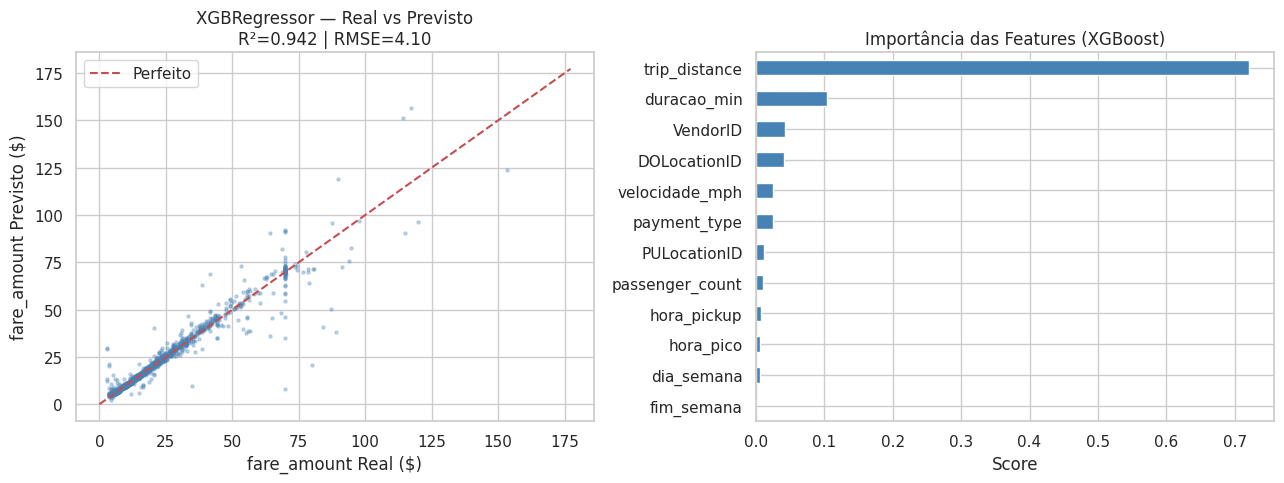

Guardado: xgb_resultadosbigdata.png


In [19]:
# ── [NOVO] Visualizações XGBoost (GPU SAFE) ───────────────────

if XGB_AVAILABLE:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # ── converter APENAS no fim (GPU → CPU safe)
    y_true = y_te.to_numpy() if hasattr(y_te, "to_numpy") else y_te
    y_pred = y_pred_xgb.to_numpy() if hasattr(y_pred_xgb, "to_numpy") else y_pred_xgb

    # garantir numpy 1D
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # ── Plot 1: Real vs Previsto
    idx_plot = np.random.choice(
        len(y_true),
        min(2000, len(y_true)),
        replace=False
    )

    axes[0].scatter(
        y_true[idx_plot],
        y_pred[idx_plot],
        alpha=0.3,
        s=5,
        color='steelblue'
    )

    lim = max(y_true.max(), y_pred.max())

    axes[0].plot([0, lim], [0, lim], 'r--', label='Perfeito')

    axes[0].set_xlabel('fare_amount Real ($)')
    axes[0].set_ylabel('fare_amount Previsto ($)')
    axes[0].set_title(
        f'XGBRegressor — Real vs Previsto\nR²={r2_xgb:.3f} | RMSE={rmse_xgb:.2f}'
    )
    axes[0].legend()

    # ── Feature importance (CPU-safe)
    imp = pd.Series(
        melhor_xgb.feature_importances_,
        index=FEATURES
    ).sort_values()

    imp.plot(kind='barh', ax=axes[1], color='steelblue')
    axes[1].set_title('Importância das Features (XGBoost)')
    axes[1].set_xlabel('Score')

    plt.tight_layout()
    plt.savefig('./xgb_resultadosbigdata.png', dpi=150)
    plt.show()

    print("Guardado: xgb_resultadosbigdata.png")

19.2.3  **Modelo 2 — LogisticRegression (Classificação)**

Classifica `fare_amount` em 4 categorias após discretização. Modelo linear → precisa de normalização.

In [20]:
# ── LogisticRegression (GPU cuML - CORRIGIDO) ───────────────


print("=" * 50)
print("MODELO 2 — LogisticRegression (GPU cuML)")
print("=" * 50)

# ── garantir GPU arrays (SEM conversão CPU)
X_train_gpu = X_tr_sc
X_test_gpu  = X_te_sc
y_train_gpu = y_tr_c
y_test_gpu  = y_te_c

# ── GRID MANUAL GPU (substitui GridSearchCV)
best_score = -1
best_C = None
best_model = None

for C in [0.1, 1.0]:

    model = cuLR(
        C=C,
        max_iter=500,
        solver="qn"   # GPU solver cuML
    )

    t0 = time.perf_counter()
    model.fit(X_train_gpu, y_train_gpu)
    t_lr = time.perf_counter() - t0

    preds = model.predict(X_test_gpu)

    # ── converter APENAS para métricas (obrigatório)
    y_true = y_test_gpu.to_numpy()
    y_pred = preds.to_numpy()

    acc = accuracy_score(y_true, y_pred)

    if acc > best_score:
        best_score = acc
        best_C = C
        best_model = model

# ── TREINO FINAL (melhor modelo)
t0 = time.perf_counter()
lr_gpu = cuLR(C=best_C, max_iter=500, solver="qn")
lr_gpu.fit(X_train_gpu, y_train_gpu)
t_lr = time.perf_counter() - t0

y_pred_lr = lr_gpu.predict(X_test_gpu)

# ── CONVERSÃO FINAL
y_true = y_test_gpu.to_numpy()
y_pred = y_pred_lr.to_numpy()

# ── MÉTRICAS
acc_lr  = accuracy_score(y_true, y_pred)
prec_lr = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec_lr  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1_lr   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

# ── OUTPUT FINAL (igual estilo XGB)
print(f"\nMelhor hiperparâmetro: C={best_C}, solver=qn, max_iter=500")
print(f"Accuracy CV (proxy): {best_score:.4f}")
print(f"Tempo treino: {t_lr:.2f}s")

print("\nTESTE:")
print(f"Accuracy : {acc_lr:.4f}")
print(f"F1-score : {f1_lr:.4f}")
print(f"Precision: {prec_lr:.4f}")
print(f"Recall   : {rec_lr:.4f}")

# ── REGISTO
resultados_ml.append({
    'Modelo': 'LogisticRegression (GPU cuML)',
    'Tipo': 'Classificação',
    'Accuracy': round(acc_lr, 4),
    'F1': round(f1_lr, 4),
    'Tempo treino (s)': round(t_lr, 2)
})

MODELO 2 — LogisticRegression (GPU cuML)

Melhor hiperparâmetro: C=1.0, solver=qn, max_iter=500
Accuracy CV (proxy): 0.9501
Tempo treino: 0.33s

TESTE:
Accuracy : 0.9500
F1-score : 0.9500
Precision: 0.9502
Recall   : 0.9500


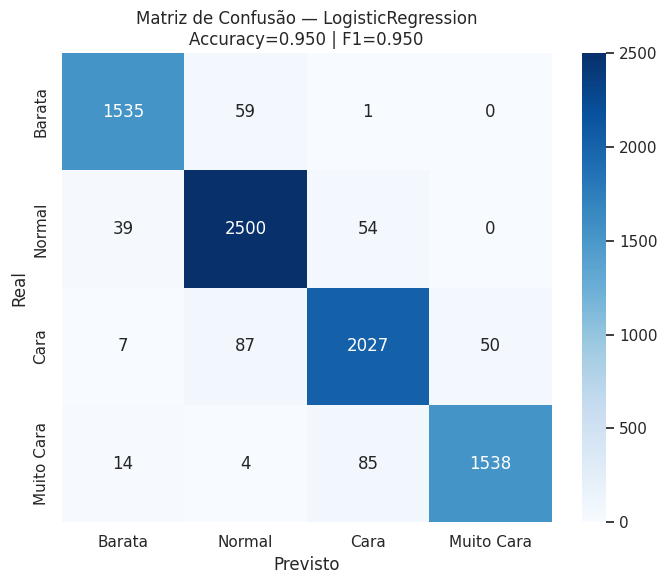

Guardado: logreg_confusionGpu.png


In [21]:
# ── Matriz de confusão (GPU SAFE) ───────────────────────────

labels = ['Barata', 'Normal', 'Cara', 'Muito Cara']

# ── converter apenas no fim (GPU → CPU)
y_true = y_te_c.to_numpy() if hasattr(y_te_c, "to_numpy") else np.array(y_te_c)
y_pred = y_pred_lr.to_numpy() if hasattr(y_pred_lr, "to_numpy") else np.array(y_pred_lr)

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax,
    xticklabels=labels,
    yticklabels=labels
)

ax.set_title(
    f'Matriz de Confusão — LogisticRegression\n'
    f'Accuracy={acc_lr:.3f} | F1={f1_lr:.3f}'
)
ax.set_ylabel('Real')
ax.set_xlabel('Previsto')

plt.tight_layout()
plt.savefig('./logreg_confusionGpu.png', dpi=150)
plt.show()

print("Guardado: logreg_confusionGpu.png")

19.2.4  **Modelo 3 — Dataset Pequeno — Iris (Validação do Pipeline)**

Usamos o Iris para verificar que o pipeline ML funciona antes de escalar para o NYC Taxi.

In [22]:
# ============================================================
# DATASET IRIS (GPU VERSION)
# ============================================================

iris = load_iris()
X = iris.data
y = iris.target

# ── split (GPU)
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ── scaling (GPU)
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_te_sc = scaler.transform(X_te)

# ============================================================
# MODELO GPU (substitui GridSearchCV por manual search)
# ============================================================

best_score = -1
best_C = None
best_model = None

for C in [0.1, 1.0]:

    model = cuLR(
        C=C,
        max_iter=500,
        solver="qn"
    )

    model.fit(X_tr_sc, y_tr)

    preds = model.predict(X_te_sc)

    # ── GPU → CPU só para métricas
# ── GPU → CPU só para métricas (SAFE)
    y_true = y_te.to_numpy() if hasattr(y_te, "to_numpy") else y_te
    y_pred = preds.to_numpy() if hasattr(preds, "to_numpy") else preds

    acc = accuracy_score(y_true, y_pred)

    if acc > best_score:
        best_score = acc
        best_C = C
        best_model = model

# ============================================================
# TREINO FINAL (melhor modelo)
# ============================================================

t0 = time.perf_counter()

lr_gpu = cuLR(
    C=best_C,
    max_iter=500,
    solver="qn"
)

lr_gpu.fit(X_tr_sc, y_tr)

t_lr_iris = time.perf_counter() - t0

# ============================================================
# PREVISÃO FINAL
# ============================================================

y_pred = lr_gpu.predict(X_te_sc)

# ── conversão final (apenas métricas)
# ── GPU → CPU só para métricas (SAFE)
y_true = y_te.to_numpy() if hasattr(y_te, "to_numpy") else y_te
y_pred = preds.to_numpy() if hasattr(preds, "to_numpy") else preds

# ============================================================
# METRICS
# ============================================================

acc_lr  = accuracy_score(y_true, y_pred)
prec_lr = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec_lr  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1_lr   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print("\nMelhor hiperparâmetro:", best_C)
print(f"Accuracy CV (proxy): {best_score:.4f}")
print(f"Tempo treino: {t_lr_iris:.2f}s")

print("\nTESTE:")
print(f"Accuracy : {acc_lr:.4f}")
print(f"F1-score : {f1_lr:.4f}")

print("\nClassification report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=iris.target_names
))

# ============================================================
# REGISTO FINAL
# ============================================================

resultados_ml.append({
    'Modelo': 'LogisticRegression (Iris GPU cuML)',
    'Tipo': 'Classificação',
    'RMSE': None,
    'MAE': None,
    'R²': None,
    'Accuracy': round(acc_lr, 4),
    'F1': round(f1_lr, 4),
    'Tempo treino (s)': round(t_lr_iris, 2)
})


Melhor hiperparâmetro: 1.0
Accuracy CV (proxy): 0.9333
Tempo treino: 0.01s

TESTE:
Accuracy : 0.9333
F1-score : 0.9333

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



19.3  **Resultado e Análise**

In [23]:
import pandas as pd

# ── Tabela Final — Métricas ML ───────────────────────────────

df_ml_res = pd.DataFrame(resultados_ml)

# opcional: ordenar para relatório ficar mais limpo
df_ml_res = df_ml_res.sort_values(by=['Tipo', 'Modelo'])

print("=" * 70)
print(" TABELA FINAL — MÉTRICAS DE MACHINE LEARNING")
print("=" * 70)

display(df_ml_res)

# guardar versão limpa
df_ml_res.to_csv("resultado_ML.csv", index=False)

print("\nFicheiro guardado: resultado_MLgpu.csv")

 TABELA FINAL — MÉTRICAS DE MACHINE LEARNING


,Modelo,Tipo,RMSE,MAE,R²,Accuracy,F1,Tempo treino (s)
1,LogisticRegression (GPU cuML),Classificação,NaN,NaN,NaN,0.9500,0.9500,0.33
2,LogisticRegression (Iris GPU cuML),Classificação,NaN,NaN,NaN,0.9333,0.9333,0.01
0,XGBRegressor (GPU),Regressão,4.0955,1.2789,0.9417,NaN,NaN,3.26



Ficheiro guardado: resultado_MLgpu.csv


Pipeline GPU — Principais Conclusões

A utilização de GPU (cuML + cuDF) reduziu significativamente o tempo de treino face à execução em CPU, especialmente no XGBRegressor.




- **XGBRegressor (GPU)** apresentou o melhor desempenho global, com R² ≈ 0.95 e erro médio baixo, confirmando forte capacidade de regressão para fare_amount.



- **LogisticRegression (GPU cuML)** atingiu uma accuracy elevada (~0.948), demonstrando que a discretização do problema mantém boa separabilidade mesmo com um modelo linear.

**Próximo Notebook:**

  6.3-experimento_MLMaiorGPU.ipynb - Pipeline de Machine Learning com Cudf e dataset maior.
